# Spatial cell-cell communication with CellChat


Adapted from the tutorial for SpatialCellChat. 

[SpatialCellChat_analysis_of_spatial_transcriptomics_data]('https://htmlpreview.github.io/?https://github.com/jinworks/SpatialCellChat/blob/master/tutorial/SpatialCellChat_analysis_of_spatial_transcriptomics_data.html')

For speed, we ran the actual processing for SpatialCellChat in a separate script, but this notebook shows the subset used for input and the subsequent visualization.

In [1]:
## sbatch --mem=100G -p tier2q  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/seurat_spatial

## LIBRARIES
library(Seurat)
library(SpatialCellChat)
library(Matrix)
library(dplyr)
library(ggplot2)
library(patchwork)

options(stringsAsFactors = F)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## Prepare Seurat object

In [ ]:
## Create seurat object with Subset data. 
in_dir = './CosMx/results/Subset_MM'
out_dir = './CosMx/results/SpatialCellChat'
dir.create(out_dir, showWarnings = F)

# 1. Load counts and create base object
## Read mtx file directly 
counts = readMM(file.path(in_dir, "matrix.mtx"))
barcodes = read.table(file.path(in_dir, "barcodes.tsv"), header = FALSE)$V1
features = read.table(file.path(in_dir, "features.tsv"), header = FALSE, sep = "\t")

rownames(counts) = features$V2  # gene names (col 2), or V1 for IDs
colnames(counts) = barcodes

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


In [25]:
## Create base obj
seurat_obj = CreateSeuratObject(counts = counts)

# 2. Add cell metadata (with annotations)
metadata = read.csv(file.path(in_dir, "metadata_annotation.csv"), row.names = 1)
## Remove ct_ columns and rename final_annotation to cell_type for clarity. 
metadata = dplyr::select(metadata, -starts_with('ct_')) %>% dplyr::rename(cell_type = 'final_annotation')

# Make sure cell names match
all(rownames(metadata) == colnames(seurat_obj))  # should be TRUE

## add Metadata and set Identities.
seurat_obj = AddMetaData(seurat_obj, metadata)
Idents(seurat_obj) = seurat_obj$cell_type

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


[1] TRUE

In [26]:
head(seurat_obj)

,orig.ident,nCount_RNA,nFeature_RNA,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,⋯,Area.um2,cell,n_genes_by_counts,total_counts,total_counts_negative_probe,pct_counts_negative_probe,leiden_0.2,leiden_0.4,leiden_0.6,cell_type
,<fct>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,⋯,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
43430,SeuratProject,2183,1350,70,7370,0.61,63,38,126,77,⋯,106.62552,c_1_70_1,1371,2209,0,0.00000000,0,0,0,LummHR-SCGB
43431,SeuratProject,3563,2250,70,7594,0.97,489,54,105,108,⋯,109.86624,c_1_70_2,2285,3601,1,0.02777006,0,2,3,LummHR-SCGB
43432,SeuratProject,2879,1830,70,7630,0.97,578,58,112,116,⋯,110.38707,c_1_70_3,1861,2911,2,0.06870491,0,2,3,LummHR-SCGB
43433,SeuratProject,1238,814,70,3466,0.63,612,27,88,55,⋯,50.14437,c_1_70_4,819,1243,0,0.00000000,0,2,0,LummHR-SCGB
43434,SeuratProject,1220,684,70,9646,0.86,876,50,116,100,⋯,139.55356,c_1_70_5,686,1222,0,0.00000000,1,4,2,Macrophages
43435,SeuratProject,1290,898,70,5142,0.88,1062,42,95,84,⋯,74.39191,c_1_70_6,906,1299,1,0.07698229,1,6,5,Macrophages
43436,SeuratProject,259,192,70,1440,0.29,1195,11,79,23,⋯,20.83321,c_1_70_7,195,263,0,0.00000000,2,1,1,Epithelial cells
43437,SeuratProject,1577,858,70,11639,0.59,1922,49,165,98,⋯,168.38730,c_1_70_8,864,1584,0,0.00000000,0,2,10,LummHR-SCGB
43438,SeuratProject,351,263,70,1074,0.34,2035,10,62,21,⋯,15.53810,c_1_70_9,264,352,0,0.00000000,2,1,1,Epithelial cells


Since this method requires more extensive computations, we will once again restrict the dataset we have and keep only a fraction of our cells to sample, as shown in the red section. 

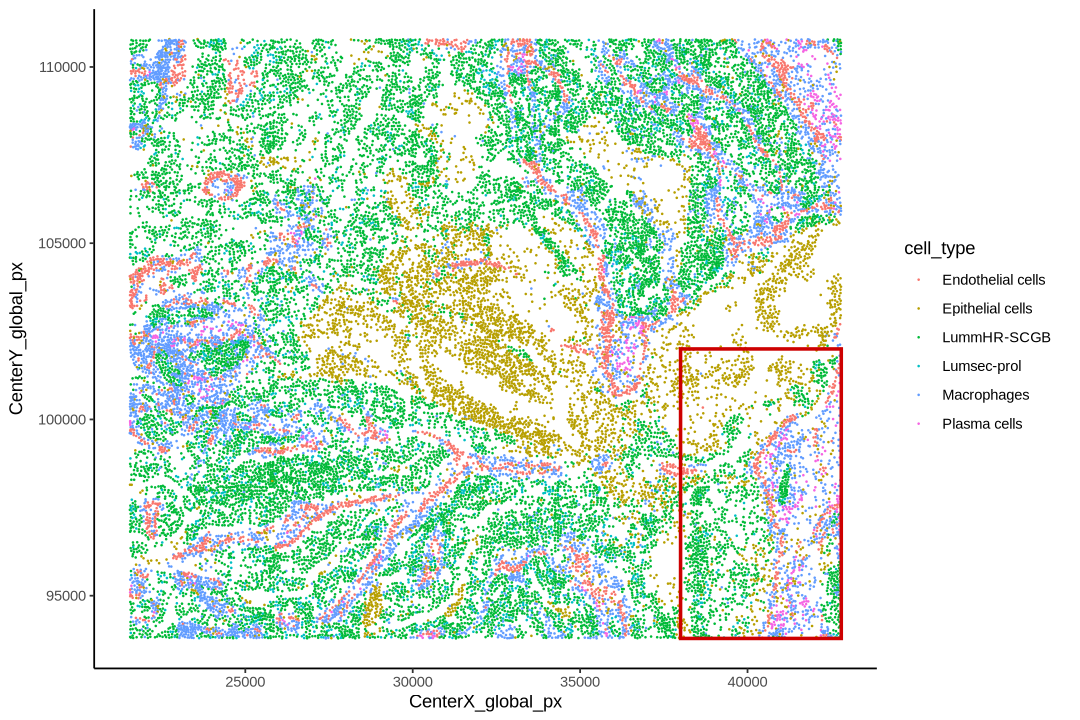

In [42]:
options(repr.plot.width = 9, repr.plot.height = 6)
ggplot(seurat_obj@meta.data, aes(x = CenterX_global_px, y = CenterY_global_px, color = cell_type)) + 
geom_point(size = 0.1) + theme_classic() + 
annotate('rect', xmin = 38000, xmax = 42800, ymin = 93787, ymax = 102000, color = 'red3', fill = 'transparent', linewidth = 1) 

In [ ]:
## Quick filter to test data. 
summary(seurat_obj$CenterX_global_px)
summary(seurat_obj$CenterY_global_px)

# with(seurat_obj@meta.data, sum(CenterX_global_px > 38000  & CenterY_global_px < 102000))

seurat_obj = subset(seurat_obj, CenterX_global_px > 38000  & CenterY_global_px < 102000)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21549   26261   31878   31812   36990   42800 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  93787   97767  102127  102220  106632  110790 

In [62]:
seurat_obj

An object of class Seurat 
20334 features across 2731 samples within 1 assay 
Active assay: RNA (20334 features, 0 variable features)
 2 layers present: counts, data

Once we have produced the Seurat object, let's make sure the normalized data is also added, or load it if you have a prefered normalized counts matrix. 

In [63]:
## 3. Normalize data
seurat_obj = NormalizeData(seurat_obj)

Normalizing layer: counts



In [ ]:
saveRDS(seurat_obj, file = file.path(out_dir, "seurat_obj_subset_SpatialCellChat.rds"))

## Spatial data formatting

For CosMx, we have 5 pieces of spatial information: 
    * FOV
    * CenterX_local_px and CenterY_local_px: Within FOV pixel position.
    * CenterX_global_px and CenterY_global_px: Global, pixel position.
    
Since we want to convert it to nm resolution, we require a conversion factor. 
For CosMx, we know that a pixel edge length is 120 nm, to convert to microns. 

`conversion.factor = 0.12028`

Since CosMx is done at the cell-level and thus, do not have uniforma cell size, we can use as a tolerance factor half the minimum centroid-to-centroid distance between cells. 

From the notes in SpatialCellChat:

[CellChat, CosMx](https://htmlpreview.github.io/?https://github.com/jinworks/CellChat/blob/master/tutorial/FAQ_on_applying_CellChat_to_spatial_transcriptomics_data.html#cosmx)

*_"CellChat does not need an accurate tolerance factor, which is used for determining whether considering the cell-pair as spatially proximal if their distance is greater than interaction.range but smaller than “interaction.range + tol”._*

In [50]:
conversion.factor = 0.12028 ## Conversion factor for CosMx. 

## Load spatial coordinates - CenterX_global_px and CenterY_global_px columns in metadata.
spatial_coords = dplyr::select(seurat_obj@meta.data, CenterX_global_px, CenterY_global_px) %>%
    rename(x = CenterX_global_px, y = CenterY_global_px) %>% as.matrix()


In [51]:
d = dist(spatial_coords, method = 'euclidean') ## Instead of computeCellDistance, function is not working well. 
## Calculate approximate spot size based on the minimum distance between spots.
spot.size = min(d)*conversion.factor # converting the distance in Pixels to Micrometers
spatial.factors = data.frame(ratio = conversion.factor, tol = spot.size/2)

## Create Spatial Cell Chat obj

In [53]:
## Create Spatial CellChat obj. 
chat = createSpatialCellChat(
    object = seurat_obj, 
    group.by = "cell_type", 
    assay = "RNA", 
    datatype = "spatial",
    coordinates = spatial_coords, 
    spatial.factors = spatial.factors
    )


ℹ Create a SpatialCellChat object from a Seurat object.
The `meta.data` slot in the Seurat object is used as cell meta information 
Create a SpatialCellChat object from spatial imaging data... 
Set cell identities for the new SpatialCellChat object 
The cell groups used for SpatialCellChat analysis are  Endothelial cells Epithelial cells LummHR-SCGB Lumsec-prol Macrophages Plasma cells 


You can choose between the human and mouse database. Here we use the human database as an example. You can select a subset of the interactions, depending on your interest, i.e. type of signaling (`annotation` column). 

In [54]:
CellChatDB = CellChatDB.human # use CellChatDB.mouse if running on mouse data

# Show the structure of the database
dplyr::glimpse(CellChatDB$interaction)

Rows: 3,234
Columns: 28
$ interaction_name         <chr> "TGFB1_TGFBR1_TGFBR2", "TGFB2_TGFBR1_TGFBR2",…
$ pathway_name             <chr> "TGFb", "TGFb", "TGFb", "TGFb", "TGFb", "TGFb…
$ ligand                   <chr> "TGFB1", "TGFB2", "TGFB3", "TGFB1", "TGFB1", …
$ receptor                 <chr> "TGFbR1_R2", "TGFbR1_R2", "TGFbR1_R2", "ACVR1…
$ agonist                  <chr> "TGFb agonist", "TGFb agonist", "TGFb agonist…
$ antagonist               <chr> "TGFb antagonist", "TGFb antagonist", "TGFb a…
$ co_A_receptor            <chr> "", "", "", "", "", "", "", "", "", "", "", "…
$ co_I_receptor            <chr> "TGFb inhibition receptor", "TGFb inhibition …
$ evidence                 <chr> "KEGG: hsa04350", "KEGG: hsa04350", "KEGG: hs…
$ annotation               <chr> "Secreted Signaling", "Secreted Signaling", "…
$ interaction_name_2       <chr> "TGFB1 - (TGFBR1+TGFBR2)", "TGFB2 - (TGFBR1+T…
$ is_neurotransmitter      <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FAL…
$ ligand.symbol 

In [55]:
table(CellChatDB$interaction$annotation)


    Cell-Cell Contact          ECM-Receptor Non-protein Signaling 
                  536                   424                   994 
   Secreted Signaling 
                 1280 

In [56]:
## Set the database to use for this analysis.  For this case, only cell-cell contact. 
CellChatDB_subset = subsetDB(CellChatDB, search = list(c("Cell-Cell Contact")), key = c("annotation"))
chat@DB = CellChatDB_subset

## Preprocessing data

In this step, we identify spatially-variable genes, and then identify spatially-variable interactions, defined as such if ligand and/or receptor was spatially-variable. 

In [ ]:
# subset the expression data of signaling genes for saving computation cost
chat = subsetData(chat) # This step is necessary even if using the whole database
chat = preProcessing(chat) # the function now requires only 1 argument, which is the object itself

ℹ Pre-processing from a SpatialCellChat object.
✔ Pre-processing is done.


In [ ]:
chat

An object of class SpatialCellChat created from a single dataset 
 20334 genes.
 2731 cells. 
SpatialCellChat analysis of spatial data! The input spatial locations are 
      x_cent y_cent
84062  38266 101981
84066  38160 101979
84075  38385 101977
84093  38129 101919
84099  38509 101893
84105  38298 101883

In [32]:
## Identify over-expressed genes and interactions
chat = identifyOverExpressedGenes(
  chat,
  ## Methods: 'wilcox', 'meringue' & "moransi"
  selection.method = "meringue", # method for selecting (spatially) variable features
  do.grid = FALSE # if true, do "grid" operation to speed up computation
)

>>>  Choose spatially variable features using 'MERINGUE' method... 


Warning message in pnorm(obs, mean = ei, sd = sdi):
“NaNs produced”
Warning message in pnorm(obs, mean = ei, sd = sdi):
“NaNs produced”


>>>  The number of highly variable features is 14 


In [ ]:
chat = identifyOverExpressedInteractions(chat, variable.both = F) # only require that either ligand or receptor from one pair is over-expressed

## Communication probabilities and network at the individual cell level

In [ ]:
## 5. Compute communication probability and infer cellular communication network.
## Play with the parameters to find best scale.distance value, or set to NULL. 
## Ranges and scale is base on the units of the spatial coordinates, which for CosMx is micrometers.
chat = computeCommunProb(
  chat,
  distance.use = TRUE, 
  scale.distance = 1,  ## 1-1 Since CosMx is already adjusted to micrometers. 
  contact.dependent = TRUE,
  interaction.range = 250, ## Based on expected micrometers range - paracrine signaling. 
  contact.range = 10 ## Based on expected micrometers range - juxtacrine/contatc-dependent signaling.
)

In [ ]:
## Filter out to keep only significant interactions. 
chat = filterProbability(chat)

## Filter based on number of cells supporting the interaction.
chat = filterCommunication(
  chat, min.cells = NULL,
  min.links = 10,
  min.cells.sr = 10
)

In [ ]:
##  Infer network at cell-group level. 
chat = computeAvgCommunProb(
  chat,
  avg.type = 'avg',
  nboot = 100,
  do.permutation = T
)
## Filter based on number of cells supporting the interaction.
chat = filterCommunication(
  chat, min.cells = NULL,
  min.links = 10,
  min.cells.sr = 10
)

In [ ]:
## Aggregate the cell-cell communication network.
chat = computeCommunProbPathway(chat)

## Add pathway information. 
chat = aggregateNet(chat)


In [ ]:
chat = netAnalysis_computeCentrality(
  chat,
  slot.name = "net",
  do.group = F,
  degree.only = T
)

# Results visualization

We load the computed results produced in `4_cosmx_spatial_cell_com.R`. 

In [2]:
## LIBRARIES
library(Seurat)
library(SpatialCellChat)
library(Matrix)
library(dplyr)
library(ggplot2)
library(patchwork)

In [33]:
chat = readRDS('./CosMx/results/SpatialCellChat/SpatialCellChat.rds')

In [34]:
chat

An object of class SpatialCellChat created from a single dataset 
 20334 genes.
 2731 cells. 
SpatialCellChat analysis of spatial data! The input spatial locations are 
      x_cent y_cent
84062  38266 101981
84066  38160 101979
84075  38385 101977
84093  38129 101919
84099  38509 101893
84105  38298 101883

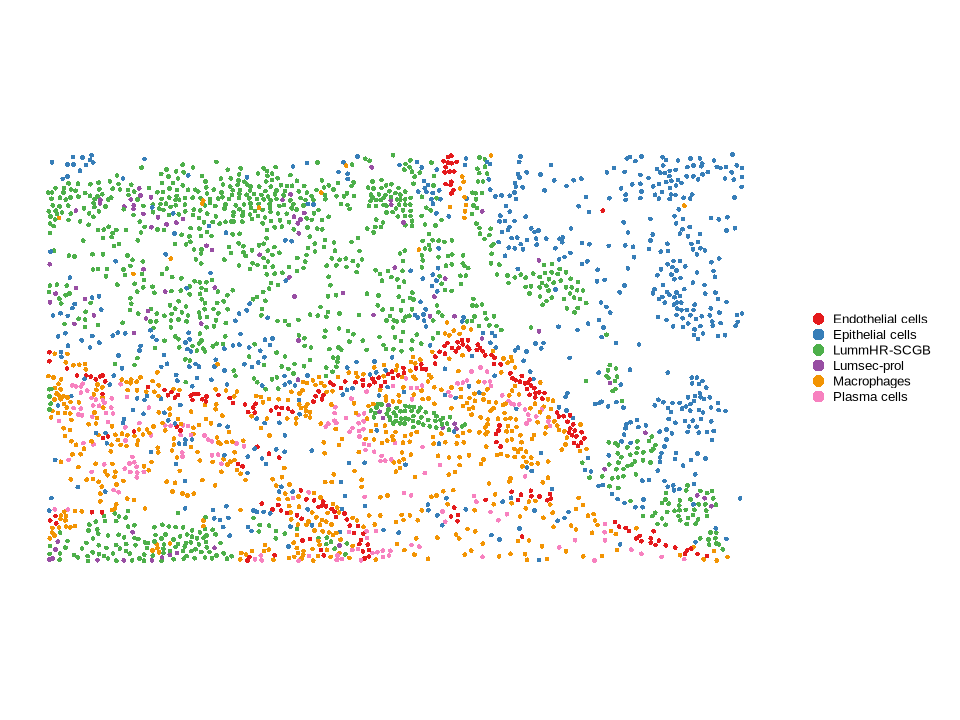

In [35]:
options(repr.plot.width = 8, repr.plot.height = 6)
spatialDimPlot(chat, group.by='cell_type', point.size = 1)

In [36]:
str(chat@netP)

List of 5
 $ pathways     : chr [1:65] "MHC-I" "ADGRL" "UNC5" "ADGRB" ...
 $ prob         : num [1:6, 1:6, 1:65] 0.0893 0 0 0 0.0473 ...
  ..- attr(*, "dimnames")=List of 3
  .. ..$ : chr [1:6] "Endothelial cells" "Epithelial cells" "LummHR-SCGB" "Lumsec-prol" ...
  .. ..$ : chr [1:6] "Endothelial cells" "Epithelial cells" "LummHR-SCGB" "Lumsec-prol" ...
  .. ..$ : chr [1:65] "MHC-I" "ADGRL" "UNC5" "ADGRB" ...
 $ pathways.cell: chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
 $ prob.cell    :List of 6
  ..$ i       : int [1:87869] 7 26 56 53 70 71 95 94 95 96 ...
  ..$ j       : int [1:87869] 7 26 56 58 70 70 91 94 95 95 ...
  ..$ k       : int [1:87869] 1 1 1 1 1 1 1 1 1 1 ...
  ..$ x       : num [1:87869] 0.0387 0.0845 0.013 0.0303 0.0431 ...
  ..$ dim     : int [1:3] 2731 2731 81
  ..$ dimnames:List of 3
  .. ..$ : chr [1:2731] "84062" "84066" "84075" "84093" ...
  .. ..$ : chr [1:2731] "84062" "84066" "84075" "84093" ...
  .. ..$ : chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
  ..- at

In [37]:
chat@netP$pathways

[1] "MHC-I"     "ADGRL"     "UNC5"      "ADGRB"     "ADGRE"     "APP"      
 [7] "NOTCH"     "ADGRG"     "NRXN"      "CADM"      "NECTIN"    "SEMA6"    
[13] "EPHA"      "PTPR"      "ICAM"      "Netrin"    "CLEC"      "GAP"      
[19] "DESMOSOME" "CLDN"      "JAM"       "SEMA4"     "CD96"      "ApoA"     
[25] "SELPLG"    "CEACAM"    "CNTN"      "SEMA5"     "ADGRA"     "MHC-II"   
[31] "EPHB"      "PTPRM"     "CD99"      "MPZ"       "CD86"      "CD39"     
[37] "PVR"       "L1CAM"     "CD40"      "NCAM"      "SN"        "ApoB"     
[43] "NKG2D"     "CDH"       "FLRT"      "SEMA7"     "CSPG4"     "VCAM"     
[49] "ApoE"      "CD23"      "PDL2"      "SELL"      "PD-L1"     "VISTA"    
[55] "PECAM2"    "EPGN"      "NGL"       "CD160"     "CD200"     "CD276"    
[61] "CDH1"      "CD48"      "THY1"      "ICOS"      "CD80"

In [38]:
chat@netP$prob %>% dim

[1]  6  6 65

**Check number of interactions per cell type**

We first use the information per Ligand-Receptor pairs to investigate the number of interactions between cell types. 



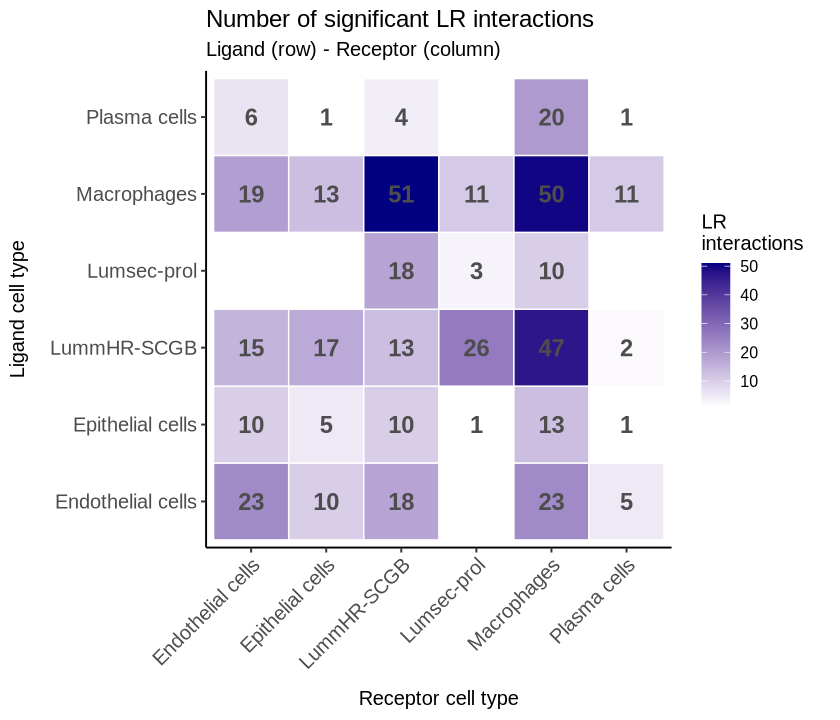

In [45]:
## Using the computeCommunProb function, we can get the communication probabilities at the signaling pathway level and L-R pair level.
## Get the communication probabilities at the signaling pathway level.

#    Extract interaction-level probabilities 
# chat@net$prob is a (cell_type × cell_type × LR_pair) array
# chat@net$pval is the matching p-value array

prob  = chat@net$prob   # dim: [sender, receiver, n_interactions]
pval  = chat@net$pval

#   Count significant LR pairs per sender–receiver pair
sig = (prob > 0) & (pval < 0.05)   

# Sum across the 3rd dimension (LR pairs) - matrix: (sender × receiver)
count_mat = apply(sig, c(1, 2), sum)

#  Format table
ct = dimnames(prob)[[1]]   # cell type names

count_df = as.data.frame(as.table(count_mat)) %>%
  setNames(c("Sender", "Receiver", "n_interactions")) %>%
  filter(n_interactions > 0)

options(repr.plot.width = 7, repr.plot.height = 6)
#   Heatmap: sender (y) × receiver (x), fill = n interactions
ggplot(count_df, aes(x = Receiver, y = Sender, fill = n_interactions)) +
  geom_tile(color = "white", linewidth = 0.4) +
  geom_text(aes(label = n_interactions), size = 5, color = "grey30", fontface = "bold") +
  scale_fill_gradient(low = 'white', high = 'navy',
                      name = "LR\ninteractions") +
  theme_classic(base_size = 12) +
  theme(axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title    = "Number of significant LR interactions",
    subtitle = "Ligand (row) - Receptor (column)",
    x = "Receptor cell type",
    y = "Ligand cell type"
  )

We explore communication related to NOTCH pathways, which is a key pathway for cancer. 

In [46]:
this_pathway = "NOTCH"

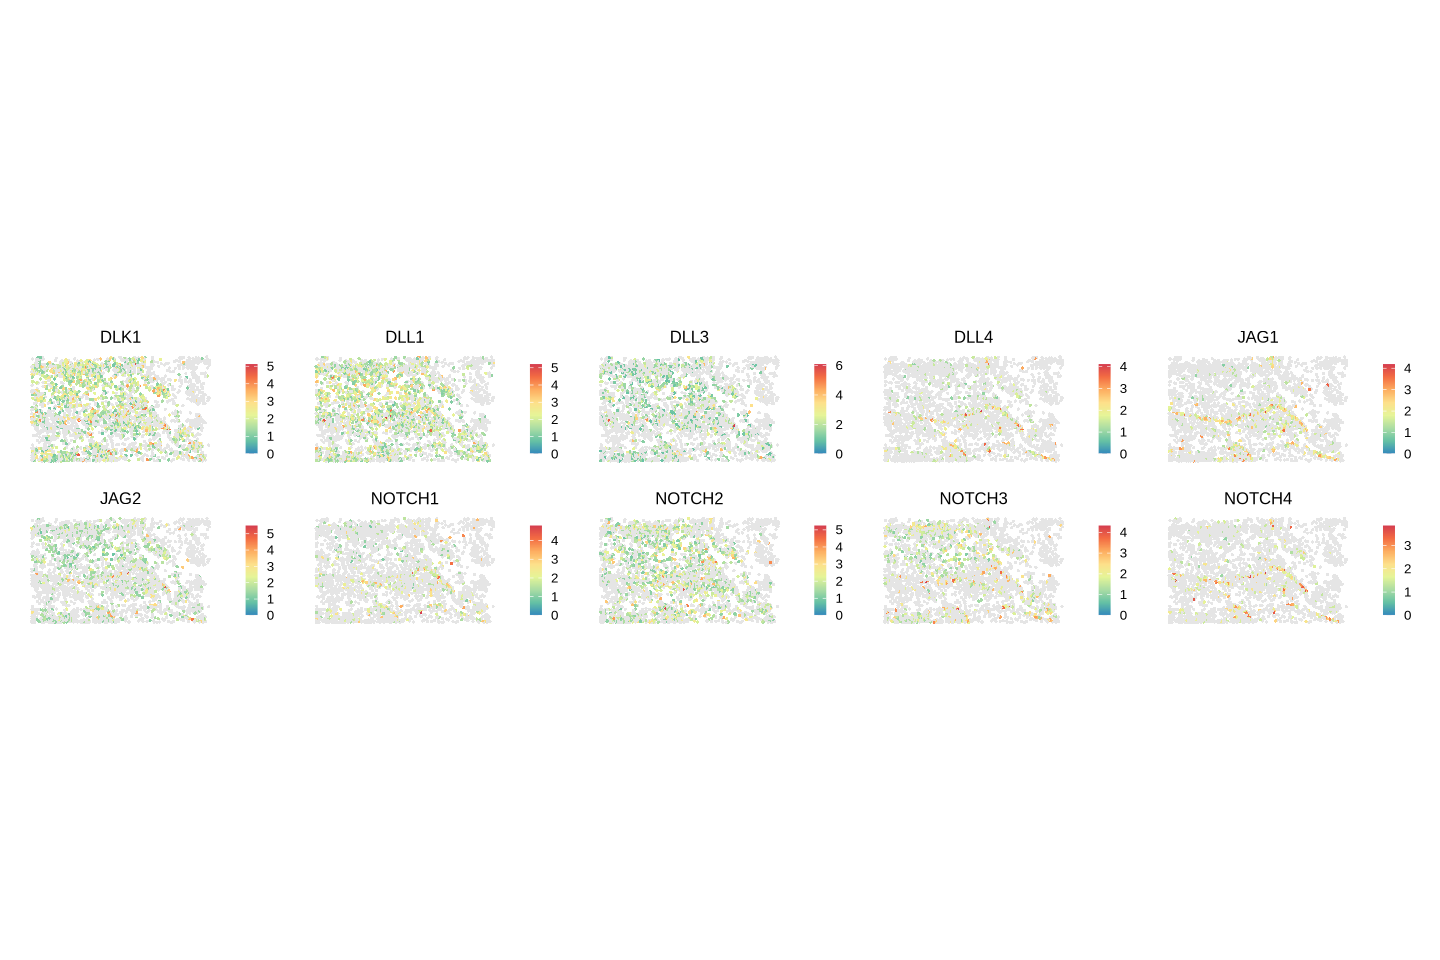

In [47]:
options(repr.plot.width = 12, repr.plot.height = 8)

# show the expression distributions of genes associated with the specific pathway
spatialFeaturePlot(chat, signaling = this_pathway, do.group = FALSE, do.binary = FALSE, color.heatmap = "Spectral", point.size = 0.6)

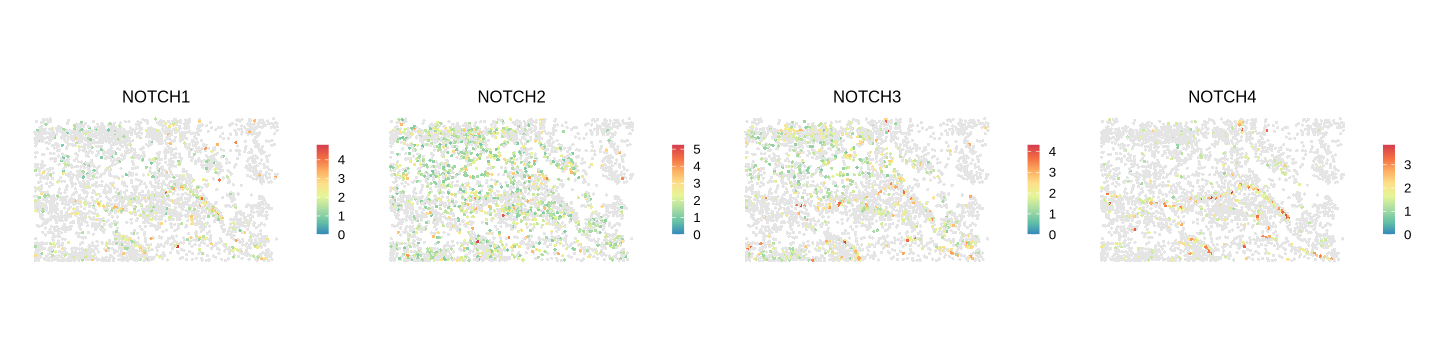

In [48]:
options(repr.plot.width = 12, repr.plot.height = 3)

# show the expression distributions of genes associated with the specific pathway
spatialFeaturePlot(chat, feature = c('NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4'), do.group = FALSE, do.binary = FALSE, color.heatmap = "Spectral", point.size = 0.6)

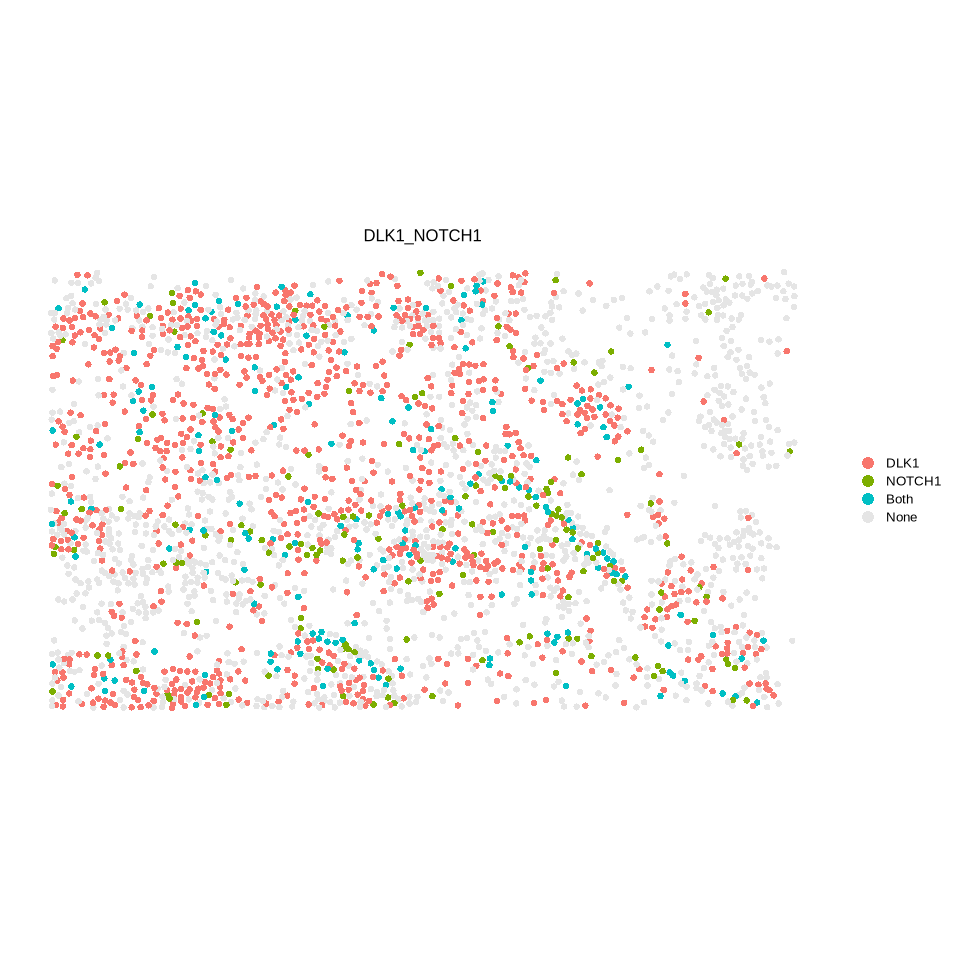

In [49]:
options(repr.plot.width = 8, repr.plot.height = 8)
# show the expression distributions of genes associated with the specific L-R pair
enrichedLR = extractEnrichedLR(chat, signaling = this_pathway, do.group = FALSE)
LR.show = enrichedLR[1,,drop = FALSE] # only show one ligand-receptor pair
spatialFeaturePlot(chat, pairLR.use =  LR.show, do.group = FALSE, do.binary = TRUE, cutoff = 0.05, point.size = 1.5)
